# In-room filtration scale-up

`src/scale_up_model.py` implements methods section 2.3. It estimates global
annual production of commercial portable air cleaners, DIY Corsi-Rosenthal
boxes and DIY units repurposed from coal-plant baghouse filters, allocates that
production across countries by manufacturing value added, converts it to an
equivalent clean air delivery rate (eCADR) and spreads it over a weekly
timeline. All three scenarios are run on every execution.

Every number lives in `data/scale_up/parameters.csv` (uncertain, sampled) or
`data/scale_up/settings.csv` (fixed), so nothing is hard-coded in the model.

Run the scripts from the repository root, in this order:

```bash
python src/essential_workers.py                          # workforce requirements
python src/linear_models.py                              # fits, updates settings.csv
python src/scale_up_model.py                             # results/scale_up/PACs_prioritized/ and CR_boxes_prioritized/
python scripts/visualization/plot_filtration_coverage.py  # the three figures
```

Both model scripts stop rather than run on incomplete inputs.
`linear_models.py` refuses while `data/scale_up/coal_plant_airflow.csv` is
empty, and `scale_up_model.py` refuses while any parameter still has
`low == high == 0`, naming each one. Manufacturing value added is downloaded
from the World Bank on the first run and cached to
`data/scale_up/mva_world_bank.csv`; check that the printed country count is
roughly 190-200, since a much lower number means the download failed and a
stale cache was used.

This notebook walks through the model one stage at a time. It needs
`results/essential_workers/EssentialWorkersByCountry.csv`, which
`src/essential_workers.py` produces.

## 0. Setup

The model uses paths relative to the repository root, so work from there.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == 'scripts' else Path.cwd()
os.chdir(REPO)
sys.path.insert(0, str(REPO / 'src'))

import linear_models as lm
import scale_up_model as sm

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

settings = sm.load_settings()
params = sm.load_parameters()
print(f'{len(params)} uncertain parameters, {len(settings)} fixed settings')
print(f"{int(settings['n_draws'])} draws over {int(settings['weeks'])} weeks")

38 uncertain parameters, 21 fixed settings
1000 draws over 26 weeks


## 1. Inputs

`parameters.csv` gives a low and a high for every uncertain quantity, with the
distribution to sample between them. `load_parameters` refuses to return a
table while any row is still unset, so a missing number fails the run rather
than quietly defaulting to zero.

In [2]:
display(params.head(10))
display(pd.Series(settings, name='value').to_frame())

,low,high,distribution,units,note,source
parameter,,,,,,
total_air_filter_revenue_usd,1.666424e+10,2.499636e+10,normal,USD/year,"Total global air filter market revenue, the ba...",https://www.grandviewresearch.com/horizon/stat...
industrial_revenue_1_4_usd,1.545300e+08,1.888700e+08,normal,USD/year,"Industrial air filter revenue, MERV 1-4. CR_Bo...",https://www.grandviewresearch.com/horizon/outl...
industrial_revenue_5_8_usd,5.070600e+08,6.197400e+08,normal,USD/year,"Industrial air filter revenue, MERV 5-8. CR_Bo...",https://www.grandviewresearch.com/horizon/outl...
industrial_revenue_9_12_usd,1.144620e+09,1.398980e+09,normal,USD/year,"Industrial air filter revenue, MERV 9-12. CR_B...",https://www.grandviewresearch.com/horizon/outl...
industrial_revenue_13_16_usd,1.690290e+09,2.066000e+09,normal,USD/year,"Industrial air filter revenue, MERV 13-16. CR_...",https://www.grandviewresearch.com/horizon/outl...
industrial_revenue_17_20_usd,1.987830e+09,2.429570e+09,normal,USD/year,"Industrial air filter revenue, MERV 17-20. CR_...",https://www.grandviewresearch.com/horizon/outl...
pac_market_revenue_usd,1.103733e+10,1.655600e+10,normal,USD/year,Average of three market reports plus/minus 20%,https://www.fortunebusinessinsights.com/portab...
fraction_room,5.000000e-01,6.800000e-01,normal,fraction,Median 0.59 per methods; 90 percent UI generat...,https://www.mordorintelligence.com/industry-re...
fraction_merv13_plus,4.000000e-01,6.000000e-01,lognormal,fraction,Methods 2.3.1.,https://www.mordorintelligence.com/industry-re...


,value
n_draws,1000.0
weeks,26.0
random_seed,32649.0
uncertainty_interval,50.0
start_delay_weeks,2.0
utilisation_baseline,0.75
utilisation_ramp_weeks,13.0
inventory_weeks,6.0
inventory_release_weeks,2.0
repurposing_release_weeks,12.0


## 2. Fitted inputs

Two settings come from regressions rather than the literature: the coal
baghouse airflow per megawatt (methods equation 7) and the exponent that
allocates production by manufacturing value added (methods equation 3).
`linear_models.py` fits both and writes them into `settings.csv` with the R2
and sample size they came from, so there is nothing to copy by hand.

In [3]:
coal = lm.fit_coal_airflow()
pooled = lm.fit_allocator()['pooled']
print(f"baghouse airflow: {coal['slope']:,.0f} L/s per MW + {coal['intercept']:,.0f} L/s "
      f"per plant (R2 = {coal['r_squared']:.2f}, n = {coal['n']})")
print(f'MVA exponent b:   {pooled.params[1]:.3f} +/- {pooled.bse[1]:.3f} '
      f'(R2 = {pooled.rsquared:.3f}, n = {int(pooled.nobs)})')
print(f"settings.csv holds b = {settings['mva_exponent_b']}")

baghouse airflow: 1,655 L/s per MW + 39,020 L/s per plant (R2 = 0.92, n = 10)
MVA exponent b:   1.019 +/- 0.110 (R2 = 0.892, n = 40)
settings.csv holds b = 1.163


## 3. Countries and the allocation of production

The country table joins the workforce requirements from the essential worker
pipeline to World Bank manufacturing value added and to installed coal
capacity. Global production is then split between countries in proportion to
manufacturing value added raised to the fitted exponent. Countries whose
implied output falls below the minimum viable factory size are zeroed and their
share is spread over the rest.

In [4]:
np.random.seed(int(settings['random_seed']))
n = int(settings['n_draws'])
samples = sm.sample_all(params, n)
df = sm.load_country_data()

total_filters = sm.filter_production(
    samples, samples['total_air_filter_revenue_usd'], sm.MERV_BANDS
)
shares = sm.production_shares(
    df,
    settings['mva_exponent_b'],
    settings['min_country_filter_production'],
    total_filters.mean(),
)
top = pd.DataFrame({'country': df['Country Name'], 'share': shares})
display(top.nlargest(10, 'share').style.format({'share': '{:.1%}'}))

Loading country data...
  217 countries; 19 have no reported MVA and cannot manufacture
  11 countries rely on MVA older than 2022
  198 countries with MVA, 19 without
  129 of 198 fall below the 200,000 unit threshold (0.91% of production reallocated)


,country,share
35,China,38.2%
203,United States,18.5%
49,Germany,5.2%
97,Japan,4.8%
104,South Korea,2.8%
88,India,2.8%
124,Mexico,2.0%
94,Italy,1.9%
63,France,1.6%
67,United Kingdom,1.5%


## 4. Supply channels

Six channels carry eCADR. Three are manufactured over the timeline and grow
with the scenario multiplier; three are one-off transfers of units already in
service, released over a few weeks.

| Channel | Methods | What it is |
| --- | --- | --- |
| `pac` | eq. 1-2 | New commercial portable air cleaners |
| `cr_box` | eq. 4-6 | New Corsi-Rosenthal boxes, limited by filters or fans |
| `baghouse` | eq. 7-8 | New coal baghouse replacement bags |
| `repurposed_pac` | eq. 9 | Portable air cleaners pulled from non-essential workplaces |
| `repurposed_cr_box` | eq. 10 | Industrial panel filters pulled from non-essential workplaces |
| `repurposed_baghouse` | eq. 8 | Bags recovered from coal plants left idle |

In [5]:
streams = sm.build_streams(df, samples, settings, n, scenario=2, shares=shares)
weeks = int(settings['weeks'])
at_end = pd.Series(
    {name: np.median(stream[-1].sum(axis=1)) for name, stream in streams.items()},
    name=f'eCADR at week {weeks} (L/s)',
)
display(at_end.to_frame().style.format('{:,.3e}'))

  CR box production is limited by filters
    meltblown cap allows a 6.2x increase (median)


,eCADR at week 26 (L/s)
pac,2.603e+09
cr_box,1.450e+10
repurposed_pac,1.893e+09
repurposed_cr_box,7.295e+08
baghouse,4.426e+08
repurposed_baghouse,8.387e+07


## 5. Scenarios

Scenario 1 is the increase in utilisation of existing factories alone.
Scenario 3 is COVID-analogue growth in production. Scenario 2 is scenario 3
capped by the extra filters the available meltblown polypropylene supports, so
it lies between the two. Coal baghouse bags are woven synthetics or glass
rather than meltblown polypropylene, so that cap does not apply to them. This
is an assumption, as there could be competition in reality.

All scenarios share the same parameter draws, so they can be compared draw for
draw.

In [6]:
requirement = df['Indoor Vital CADR Requirement (L/s)'].to_numpy(float)
comparison = {}
for scenario, description in sm.SCENARIOS.items():
    total = sum(sm.build_streams(df, samples, settings, n, scenario, shares).values())
    result = sm.coverage(total, requirement, df, settings['uncertainty_interval'])
    globally = result[result.region == 'Global'].set_index('week')
    comparison[f'{scenario}: {description}'] = {
        f'week {week}': globally.loc[week, 'coverage_median'] for week in sm.REPORT_WEEKS
    }
display(pd.DataFrame(comparison).T.style.format('{:.1%}'))

  CR box production is limited by filters
  CR box production is limited by filters
    meltblown cap allows a 6.2x increase (median)
  CR box production is limited by filters


,week 13,week 26
1: utilisation only,10.7%,16.7%
2: meltblown capped,17.2%,33.7%
3: COVID analogue growth,17.5%,35.1%


## 6. Run the model and draw the figures

`main()` runs all three scenarios twice and writes `results/scale_up/PACs_prioritized/` (default) and `results/scale_up/CR_boxes_prioritized/`: weekly eCADR
by country and by channel, coverage of both workforces by region and week, and
the requirement each region is measured against. The figure script then reads
those files.

In [7]:
sm.main()

IN-ROOM FILTRATION SCALE-UP
Loading country data...
  217 countries; 19 have no reported MVA and cannot manufacture
  11 countries rely on MVA older than 2022

Allocating global production across countries...
  total panel filter production: 510,659,460 per year
  198 countries with MVA, 19 without
  129 of 198 fall below the 200,000 unit threshold (0.91% of production reallocated)

PACs prioritized (panel filters stay with PACs)...

Scenario 1: utilisation only
  CR box production is limited by filters
    vital workers covered globally at week 13: 10.7%
    vital workers covered globally at week 26: 16.7%
    essential workers covered globally at week 13: 4.7%
    essential workers covered globally at week 26: 7.4%

Scenario 2: meltblown capped
  CR box production is limited by filters
    meltblown cap allows a 6.2x increase (median)
    vital workers covered globally at week 13: 17.2%
    vital workers covered globally at week 26: 33.7%
    essential workers covered globally at wee

In [8]:
sys.path.insert(0, str(REPO / 'scripts' / 'visualization'))
import plot_filtration_coverage as pfc

from paths import VISUALIZATIONS_RESULTS

pfc.main(VISUALIZATIONS_RESULTS, scenario=2, week=13)

Wrote /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/visualizations/ScenarioCoverage_Manuscript.png
Wrote /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/visualizations/ScenarioCoverage_Manuscript_two_panel.png
Wrote /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/visualizations/Global_stacked_cadr.png
Wrote /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/visualizations/Global_stacked_cadr_CR_boxes_prioritized.png
Wrote /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/visualizations/FiltrationCoverageByRegion_Manuscript_Week13.png
Wrote /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/visualizations/FiltrationSupplyAndCoverage_Manuscript_Week13.png
Wrote /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/visualizations/FiltrationCoverageVital_Manuscript_Week13.png
Wrote /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/visualizations/FiltrationCoverageEssential_Manuscript_Week13.png


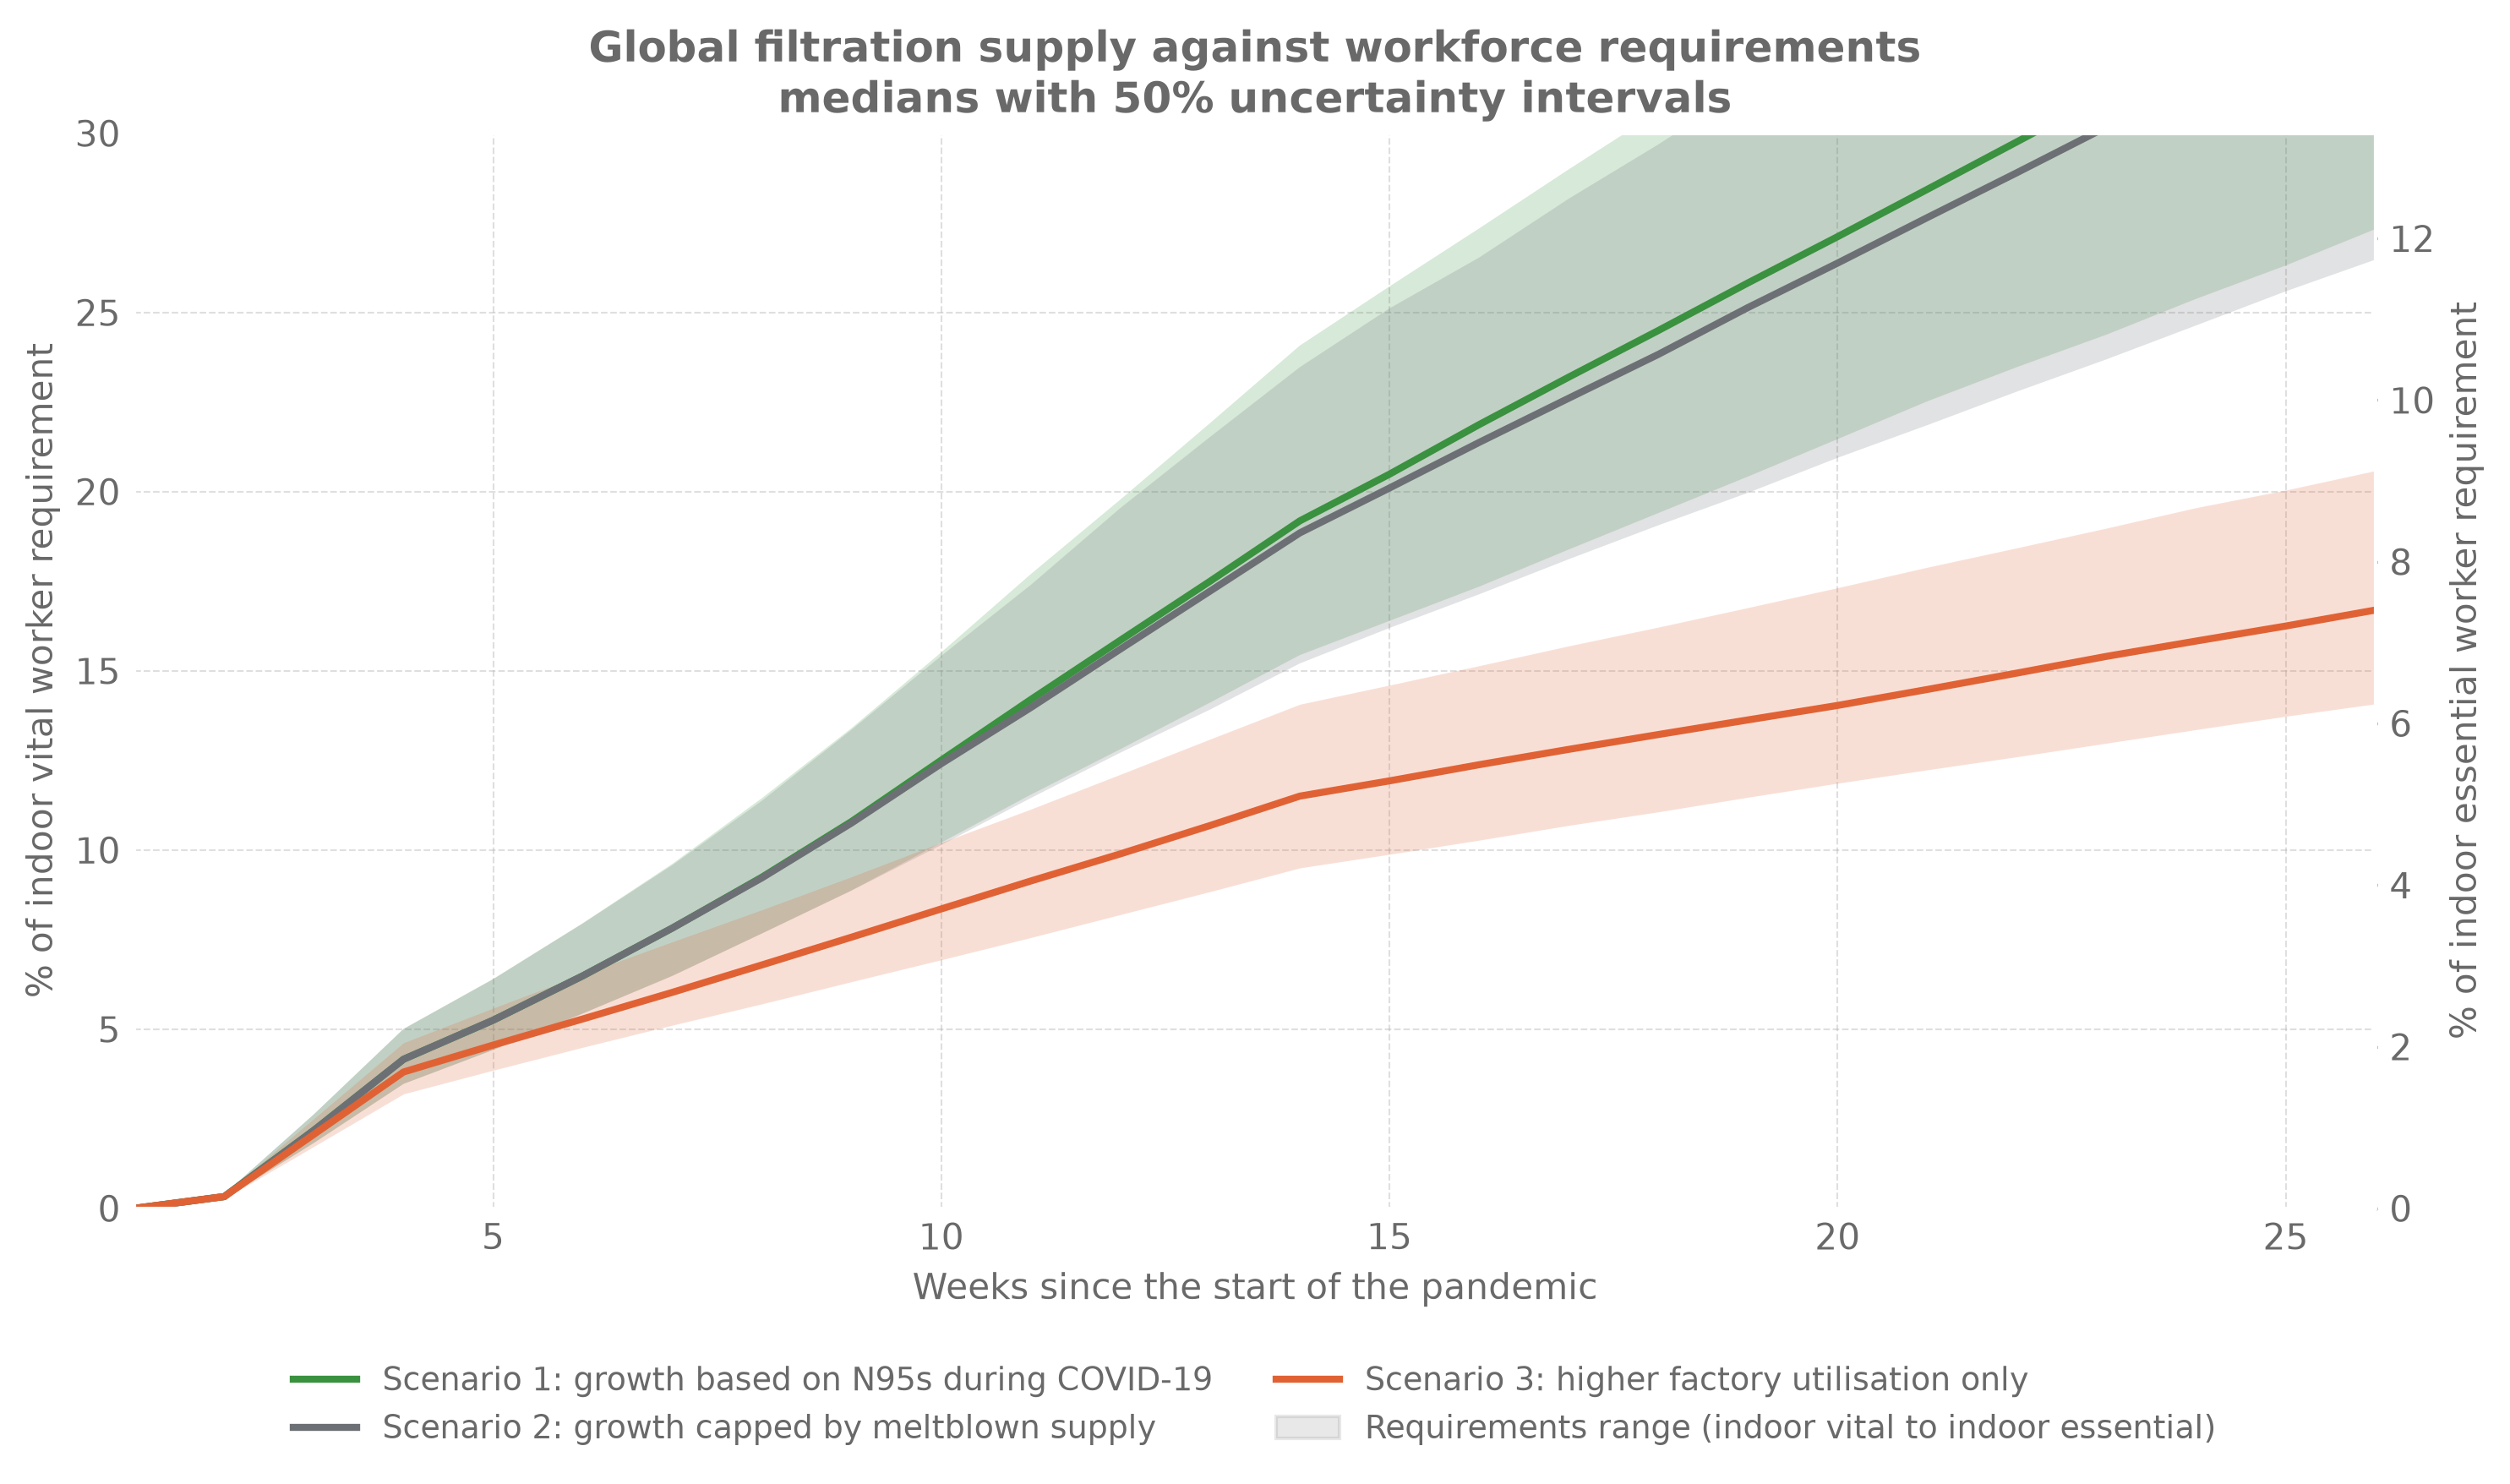

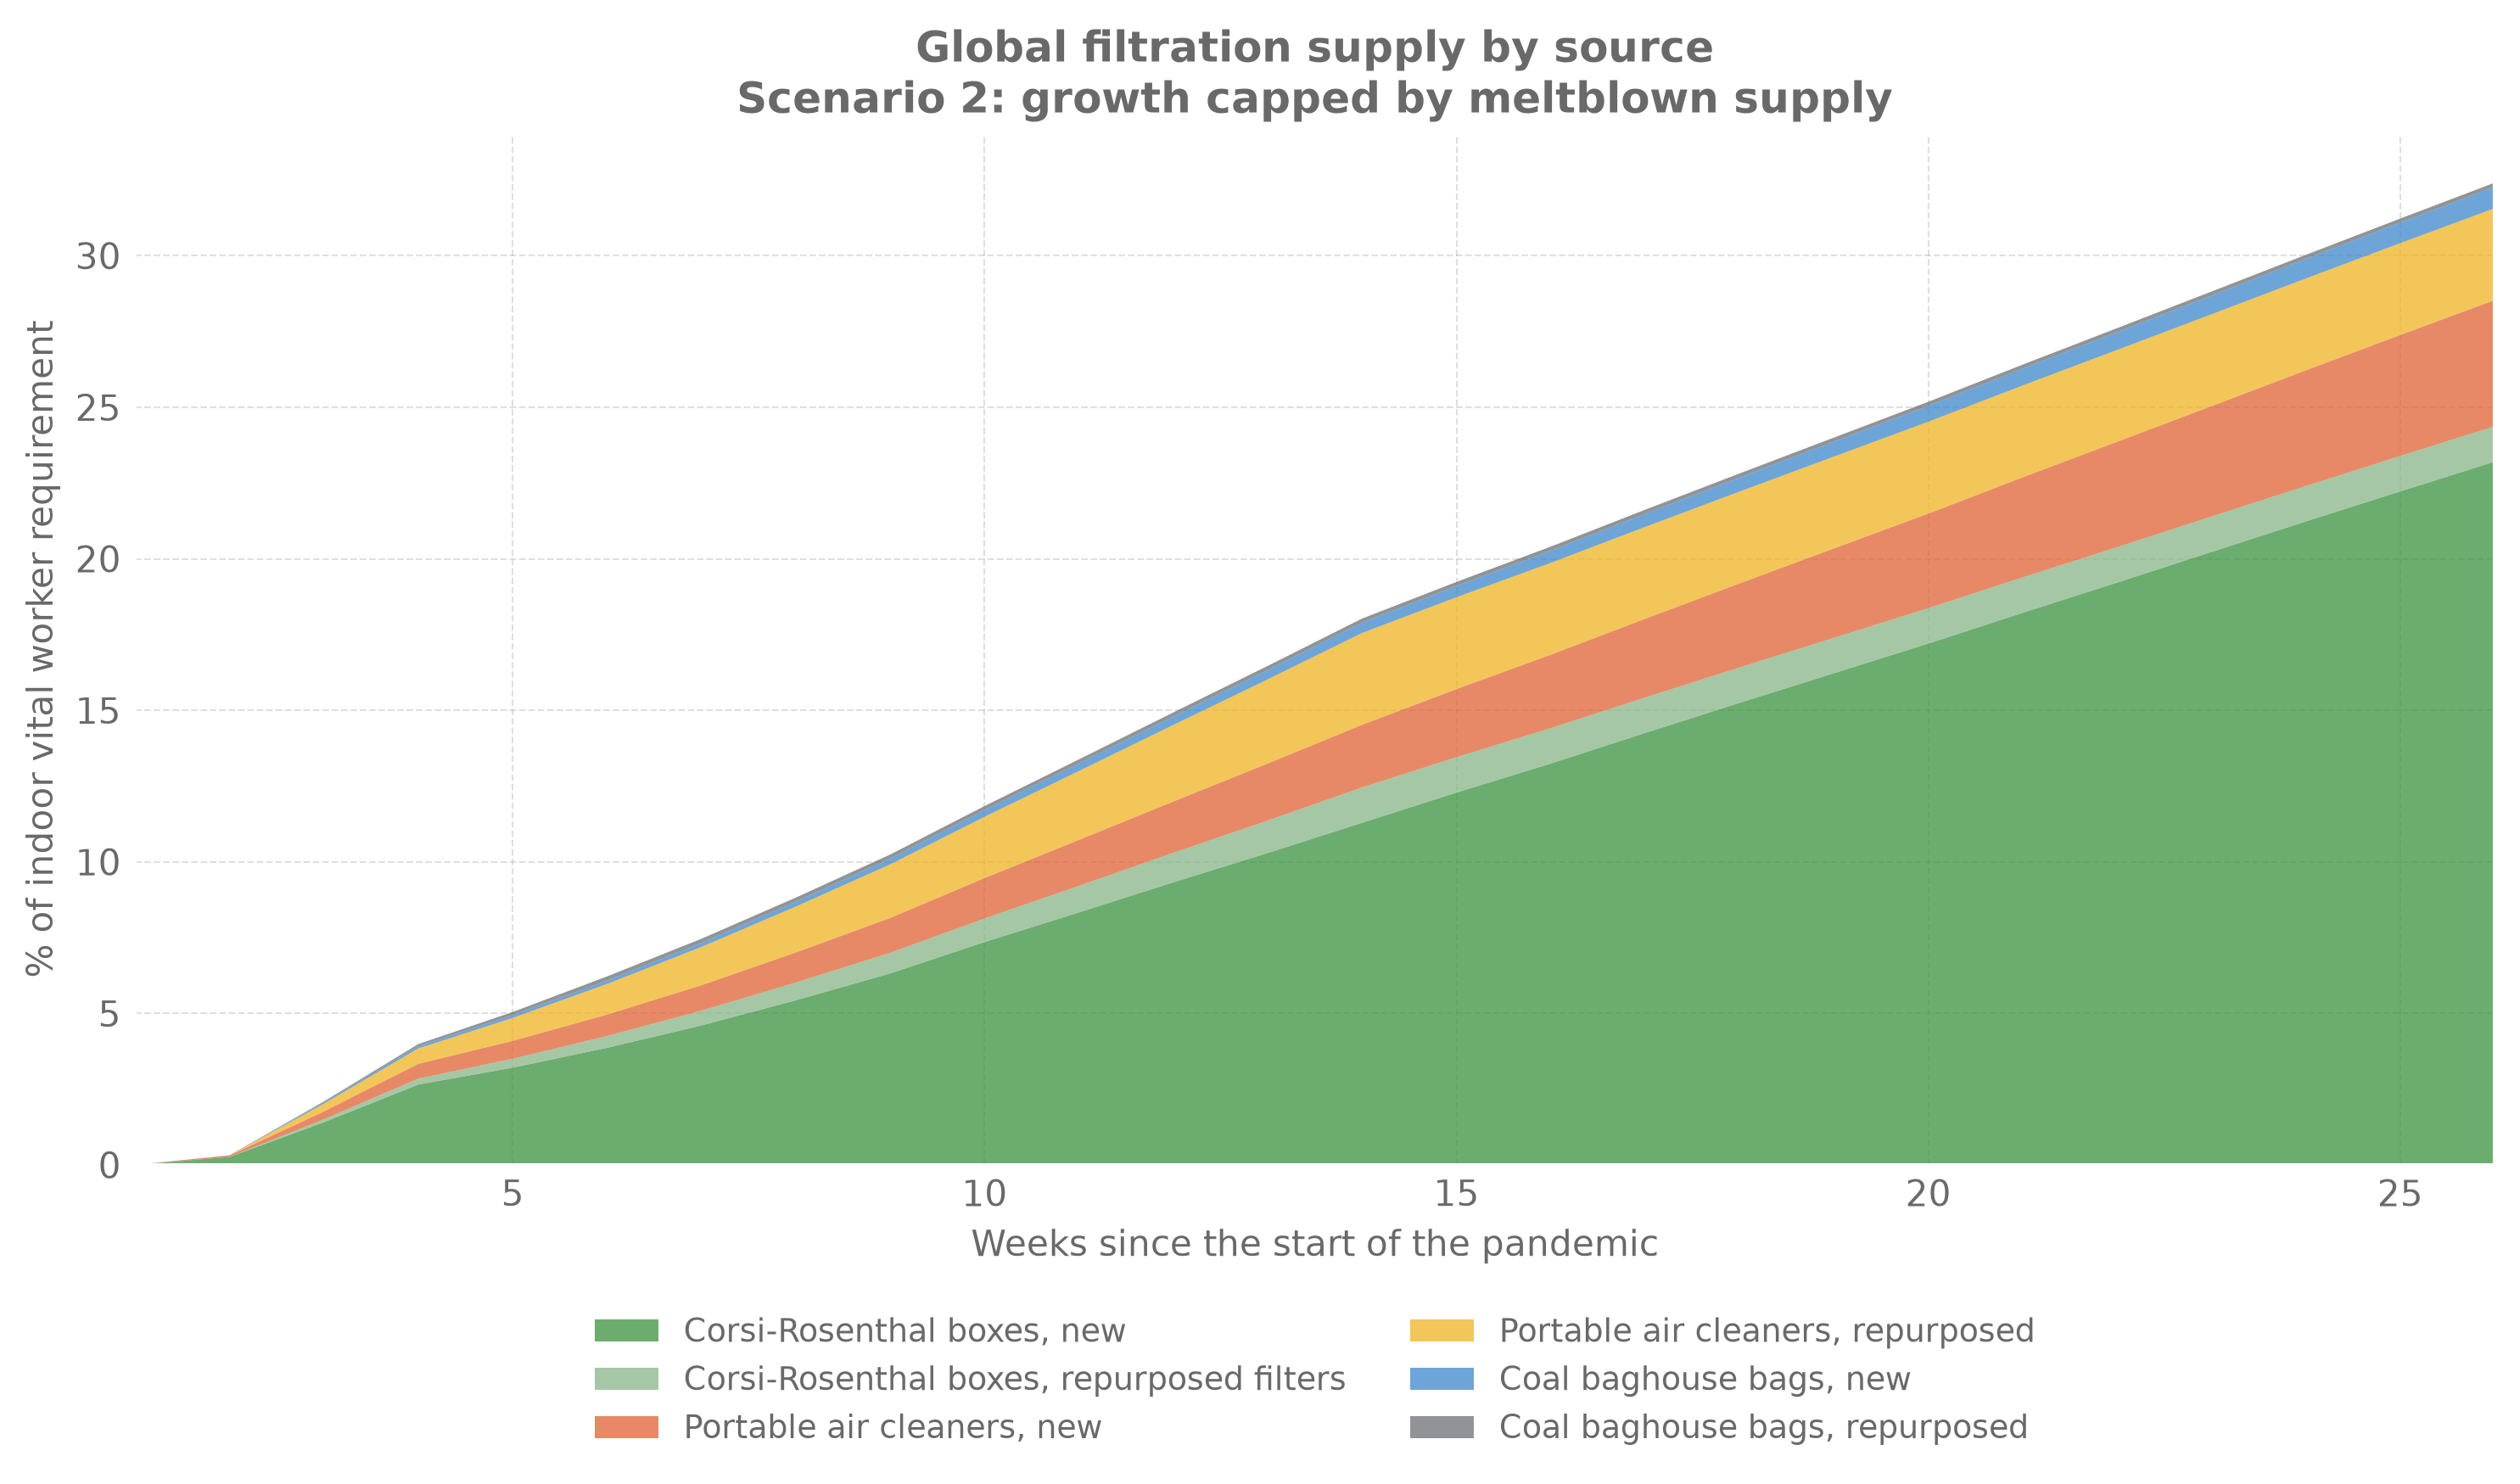

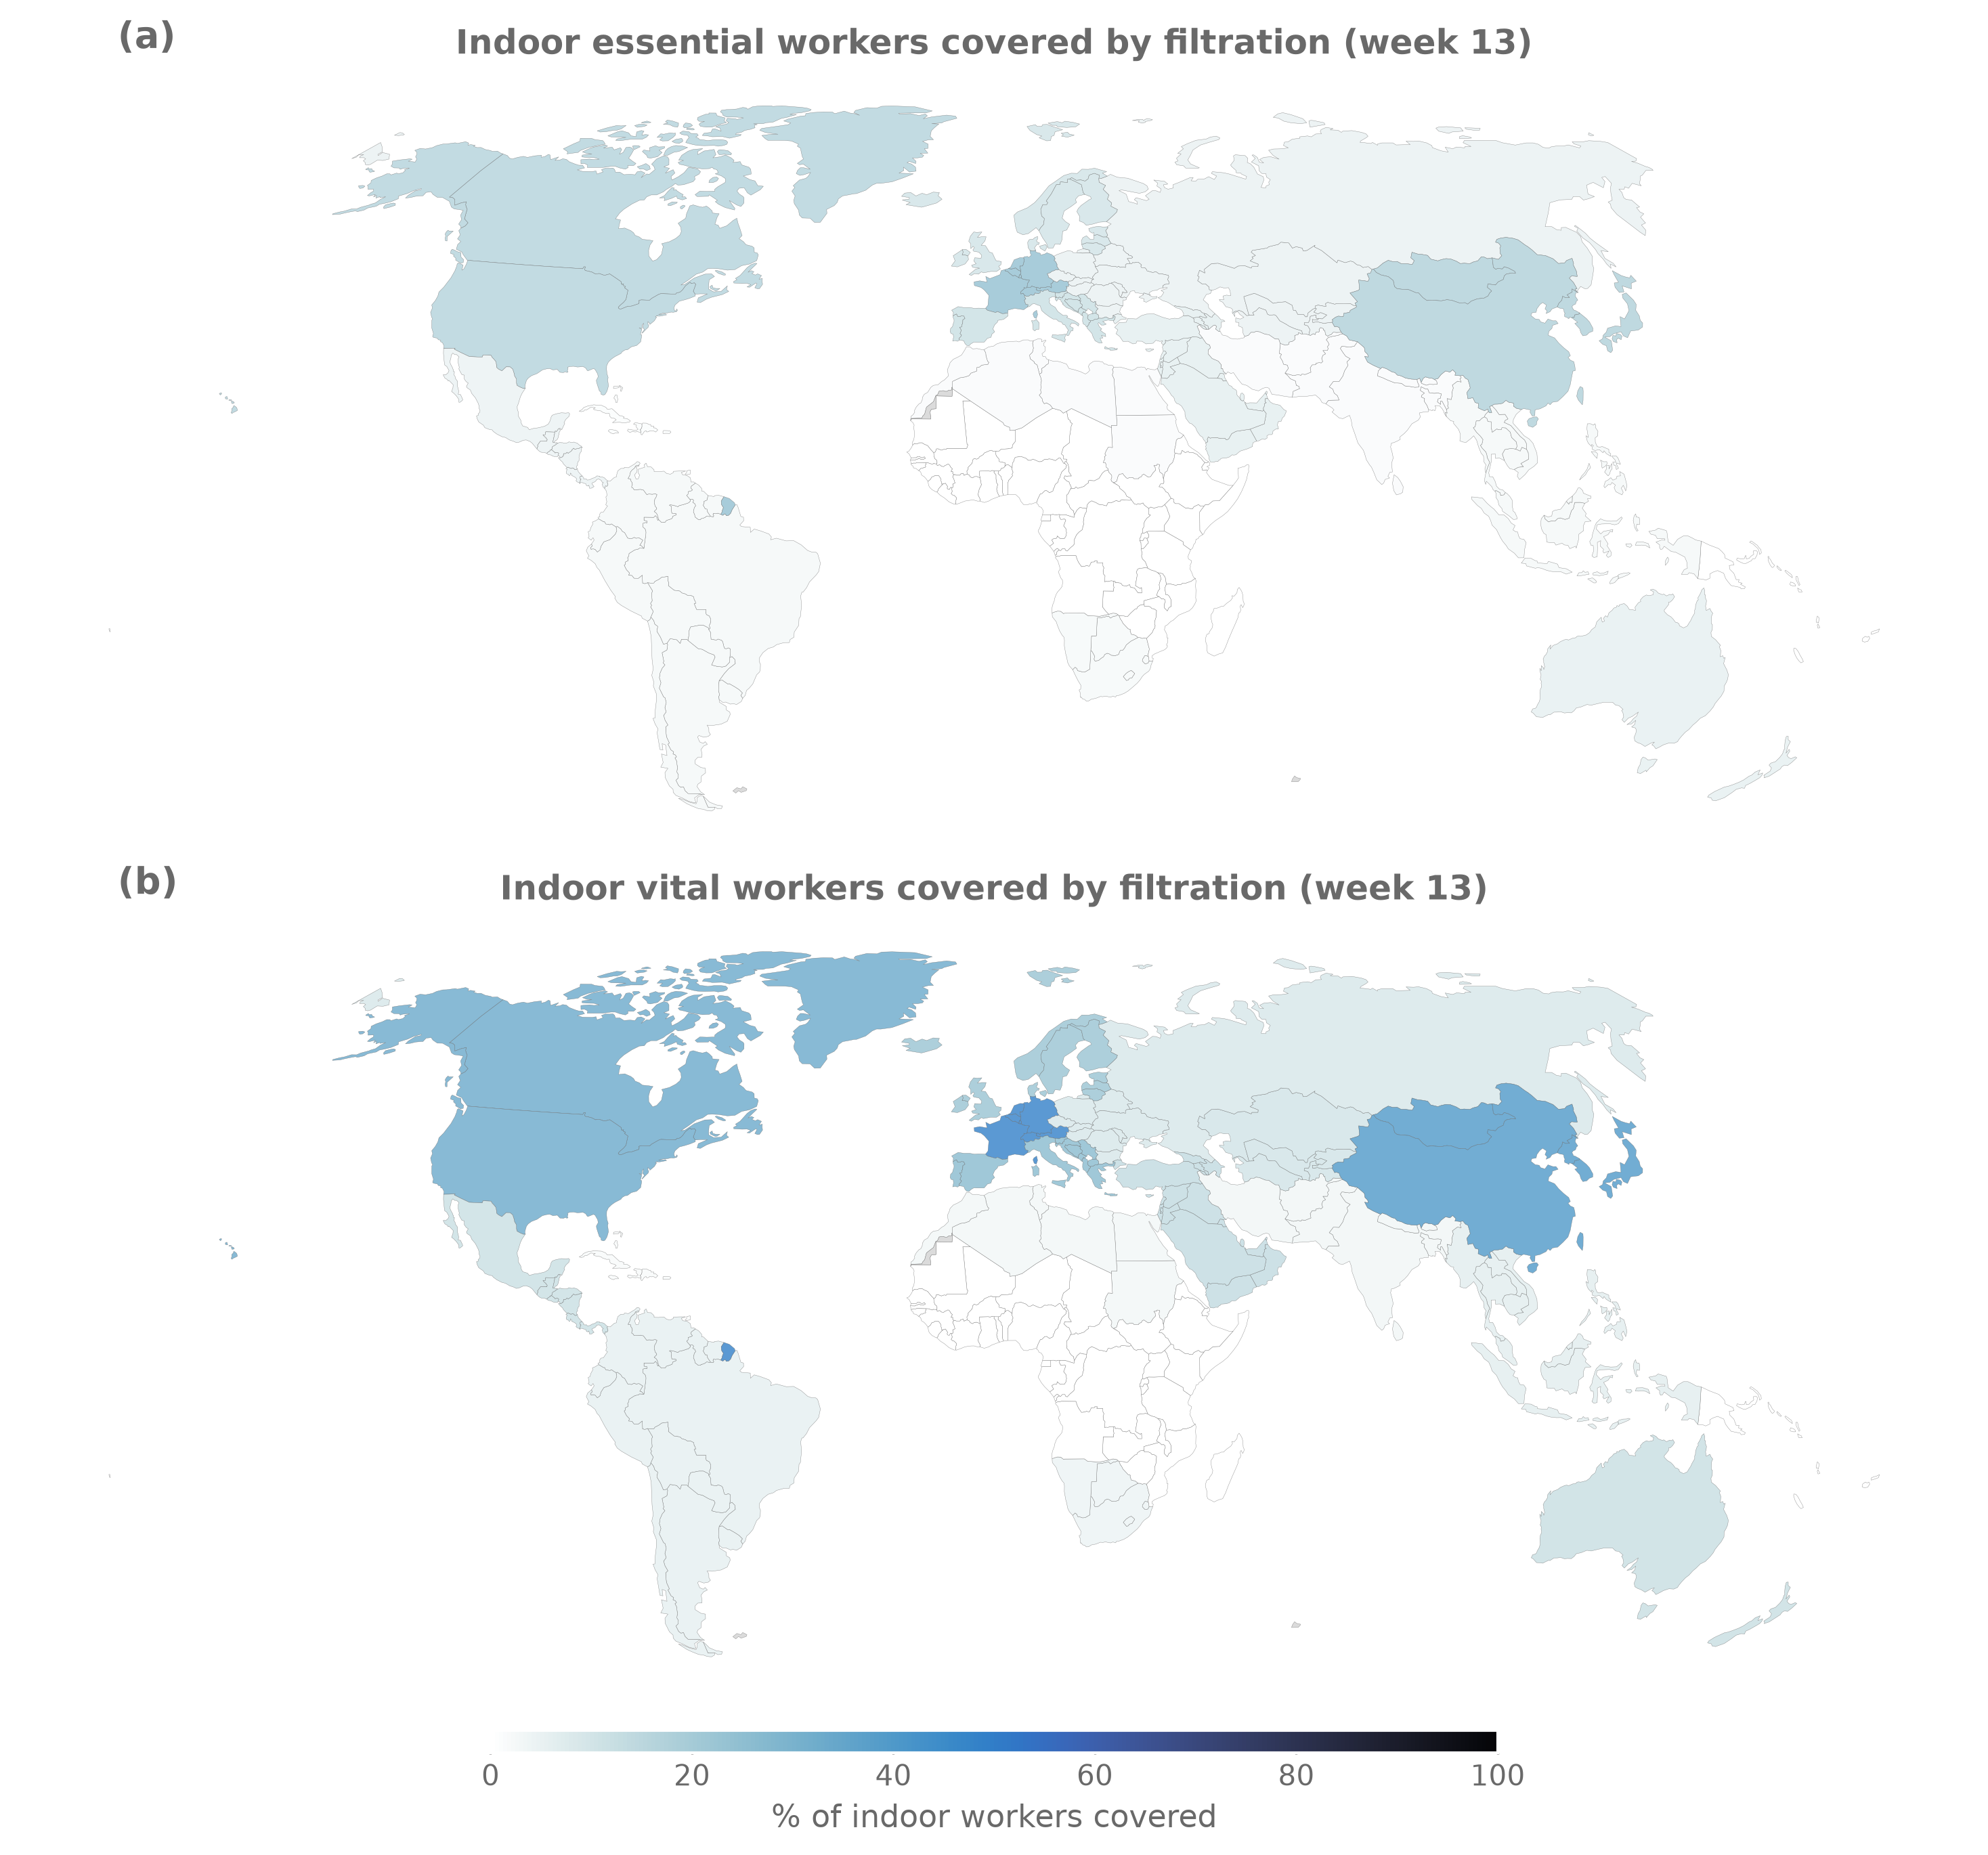

In [9]:
from IPython.display import Image, display

for name in [
    'ScenarioCoverage_Manuscript.png',
    'Global_stacked_cadr.png',
    'FiltrationCoverageByRegion_Manuscript_Week13.png',
]:
    display(Image(filename=str(VISUALIZATIONS_RESULTS / name), width=760))

## 7. Re-run the test suite

```bash
pytest tests/test_scale_up_model.py -q
```

## 8. Key results

Numbers for the in-room filtration scale-up results section of the manuscript.
Reads `results/scale_up/PACs_prioritized/` (default) and `CR_boxes_prioritized/` for the panel-filter sensitivity.
Re-run `python src/scale_up_model.py` if those CSVs are missing or stale.


In [10]:
if 'settings' not in globals():
    settings = sm.load_settings()
    params = sm.load_parameters()

from paths import PACS_PRIORITIZED_RESULTS, CR_BOXES_PRIORITIZED_RESULTS

sys.path.insert(0, str(REPO / 'scripts' / 'visualization'))
import plot_filtration_coverage as pfc

WEEK = 26
MAP_WEEK = 13
REPORT_SCENARIO = 2  # meltblown-capped growth (Figure 4 / 5)

requirements = pfc.load_requirements()
vital_requirement = requirements.loc['Global', 'indoor_vital_ecadr_l_per_s']
ui_pct = int(settings['uncertainty_interval'])
ui_label = f"{ui_pct}% UI"


def load_global_coverage(label, scenario, week, results_dir=PACS_PRIORITIZED_RESULTS):
    """Read global median coverage and uncertainty interval for one scenario."""
    path = results_dir / f"coverage_{label}_scenario{scenario}.csv"
    row = pd.read_csv(path).query("region == 'Global' and week == @week").iloc[0]
    return {
        'median': 100.0 * row['coverage_median'],
        'lower': 100.0 * row['coverage_lower'],
        'upper': 100.0 * row['coverage_upper'],
    }


def fmt_coverage(stats):
    """Format median and uncertainty interval for manuscript text."""
    return (
        f"{stats['median']:.1f}% ({ui_label}: "
        f"{stats['lower']:.1f}–{stats['upper']:.1f}%)"
    )


def channel_shares_of_requirement(channels, week, requirement):
    """Each channel as a percent of the indoor vital worker requirement."""
    row = channels.loc[week]
    return 100.0 * row / requirement


def channel_shares_of_total(channels, week):
    """Each channel as a percent of total eCADR."""
    row = channels.loc[week]
    return 100.0 * row / row.sum()


channel_labels = {
    'cr_box': 'CR box manufacturing',
    'pac': 'PAC manufacturing',
    'repurposed_pac': 'PAC repurposing',
    'repurposed_cr_box': 'CR box repurposing',
    'baghouse': 'Coal baghouse manufacturing',
    'repurposed_baghouse': 'Coal baghouse repurposing',
}

scenario_text = [
    (1, 'Factory utilisation only (75% to 100%)'),
    (3, 'COVID-analogue growth (2–6x over two months)'),
    (2, 'COVID-analogue growth capped by meltblown supply'),
]

print('=' * 72)
print('IN-ROOM FILTRATION SCALE-UP')
print('=' * 72)

print('\nGlobal coverage after 6 months (week 26), as a share of indoor CADR requirement:')
for scenario, label in scenario_text:
    vital = load_global_coverage('vital', scenario, WEEK)
    essential = load_global_coverage('essential', scenario, WEEK)
    print(f"\n{label}")
    print(f"  Indoor vital workers: {fmt_coverage(vital)}")
    print(f"  Indoor essential workers: {fmt_coverage(essential)}")

channels = pd.read_csv(
    PACS_PRIORITIZED_RESULTS / f'ecadr_by_channel_scenario{REPORT_SCENARIO}.csv',
    index_col='week',
)
shares_req = channel_shares_of_requirement(channels, WEEK, vital_requirement)
shares_total = channel_shares_of_total(channels, WEEK)

print(
    f"\nAt week {WEEK} under meltblown-capped growth, channel shares of the "
    f"indoor vital requirement:"
)
for key, label in channel_labels.items():
    print(f"  {label}: {shares_req[key]:.1f}%")
print(f"  Total: {shares_req.sum():.1f}%")

channels_cr = pd.read_csv(
    CR_BOXES_PRIORITIZED_RESULTS / f'ecadr_by_channel_scenario{REPORT_SCENARIO}.csv',
    index_col='week',
)
shares_total_default = channel_shares_of_total(channels, WEEK)
shares_total_cr = channel_shares_of_total(channels_cr, WEEK)
total_default = channels.loc[WEEK].sum()
total_cr = channels_cr.loc[WEEK].sum()
coverage_default = load_global_coverage('vital', REPORT_SCENARIO, WEEK)
coverage_cr = load_global_coverage(
    'vital', REPORT_SCENARIO, WEEK, results_dir=CR_BOXES_PRIORITIZED_RESULTS
)

print('\nPanel filters diverted to CR boxes vs PACs prioritized (default):')
print(
    f"  PAC manufacturing: {shares_total_cr['pac']:.1f}% of eCADR "
    f"(CR boxes prioritized) vs {shares_total_default['pac']:.1f}% (default)"
)
print(
    f"  Total eCADR change: {100.0 * (total_default - total_cr) / total_cr:+.1f}%"
)
print(
    f"  Global vital coverage: {coverage_cr['median']:.1f}% (CR boxes prioritized) vs "
    f"{coverage_default['median']:.1f}% (default)"
)

# Regional production shares
if 'shares' not in globals() or 'df' not in globals():
    np.random.seed(int(settings['random_seed']))
    n = int(settings['n_draws'])
    samples = sm.sample_all(params, n)
    df = sm.load_country_data()
    total_filters = sm.filter_production(
        samples, samples['total_air_filter_revenue_usd'], sm.MERV_BANDS
    )
    shares = sm.production_shares(
        df,
        settings['mva_exponent_b'],
        settings['min_country_filter_production'],
        total_filters.mean(),
    )

production_by_region = (
    pd.DataFrame({'region': df['region'], 'share': shares})
    .groupby('region', as_index=False)['share']
    .sum()
    .sort_values('share', ascending=False)
)
production_by_region['share %'] = 100.0 * production_by_region['share']

print(f"\nRegional shares of global filter production:")
for _, row in production_by_region.iterrows():
    print(f"  {row['region']}: {row['share %']:.1f}%")

coverage_vital = pd.read_csv(
    PACS_PRIORITIZED_RESULTS / f'coverage_vital_scenario{REPORT_SCENARIO}.csv'
)
coverage_map = (
    coverage_vital.loc[coverage_vital['week'] == MAP_WEEK]
    .query("region != 'Global'")
    .assign(coverage_pct=lambda d: 100.0 * d['coverage_median'])
    .sort_values('coverage_pct', ascending=False)
)

print(
    f"\nIndoor vital worker coverage at week {MAP_WEEK} "
    f"(meltblown-capped scenario), by UN region:"
)
for _, row in coverage_map.iterrows():
    print(f"  {row['region']}: {row['coverage_pct']:.1f}%")

print('\n--- Tables for copy/paste ---')
display(production_by_region.reset_index(drop=True))
display(coverage_map[['region', 'coverage_pct']].reset_index(drop=True))
display(pd.DataFrame({
    'channel': [channel_labels[k] for k in channel_labels],
    '% of vital requirement': [shares_req[k] for k in channel_labels],
    '% of total eCADR (default)': [shares_total_default[k] for k in channel_labels],
}))


IN-ROOM FILTRATION SCALE-UP

Global coverage after 6 months (week 26), as a share of indoor CADR requirement:

Factory utilisation only (75% to 100%)
  Indoor vital workers: 16.7% (50% UI: 14.1–20.6%)
  Indoor essential workers: 7.4% (50% UI: 6.2–9.1%)

COVID-analogue growth (2–6x over two months)
  Indoor vital workers: 35.1% (50% UI: 27.3–43.9%)
  Indoor essential workers: 15.6% (50% UI: 12.1–19.4%)

COVID-analogue growth capped by meltblown supply
  Indoor vital workers: 33.7% (50% UI: 26.5–42.4%)
  Indoor essential workers: 14.9% (50% UI: 11.7–18.8%)

At week 26 under meltblown-capped growth, channel shares of the indoor vital requirement:
  CR box manufacturing: 23.2%
  PAC manufacturing: 4.2%
  PAC repurposing: 3.0%
  CR box repurposing: 1.2%
  Coal baghouse manufacturing: 0.7%
  Coal baghouse repurposing: 0.1%
  Total: 32.4%

Panel filters diverted to CR boxes vs PACs prioritized (default):
  PAC manufacturing: 9.0% of eCADR (CR boxes prioritized) vs 12.9% (default)
  Total eCAD

,region,share,share %
0,Eastern Asia,0.458361,45.836128
1,Northern America,0.195120,19.511971
2,Western Europe,0.089413,8.941269
3,Southern Asia,0.039181,3.918128
4,South-eastern Asia,0.036893,3.689295
5,Northern Europe,0.033270,3.327046
6,Southern Europe,0.031135,3.113488
7,Eastern Europe,0.030010,3.001010
8,Western Asia,0.026912,2.691169
9,South America,0.022441,2.244107


,region,coverage_pct
0,Western Europe,49.085078
1,Eastern Asia,40.066820
2,Northern America,33.428225
3,Southern Europe,26.617701
4,Northern Europe,22.807233
5,Western Asia,13.759286
6,Australia and New Zealand,12.433235
7,Central America,12.113784
8,Central Asia,10.567246
9,Eastern Europe,9.297102


,channel,% of vital requirement,% of total eCADR (default)
0,CR box manufacturing,23.203193,71.601420
1,PAC manufacturing,4.164757,12.851788
2,PAC repurposing,3.028389,9.345134
3,CR box repurposing,1.167269,3.602010
4,Coal baghouse manufacturing,0.708231,2.185490
5,Coal baghouse repurposing,0.134213,0.414159
